In [1]:
import xarray as xr
from glob import glob
from pathlib import Path
from matplotlib import pyplot as plt
from dask.distributed import Client
from utils import compute_rmse

## Deterministic

In [2]:
reconstruction_files = sorted(glob("metrics/deterministic/reconstruction*"))
forecast_files = sorted(glob("metrics/deterministic/forecast*"))

In [3]:
reconstructions = {}
reconstructions_hankel = {}
for file in reconstruction_files:
    path = Path(file)
    name = path.name.split(".")[0]
    name = name.split("rmse_")[-1]
    if "hankel" in name:
        reconstructions_hankel[name] = xr.open_dataarray(file)
    else:
        reconstructions[name] = xr.open_dataarray(file)

In [4]:
forecasts = {}
forecasts_hankel = {}
for file in forecast_files:
    path = Path(file)
    name = path.name.split(".")[0]
    name = name.split("rmse_")[-1]
    if "hankel" in name:
        forecasts_hankel[name] = xr.open_dataarray(file)
    else:
        forecasts[name] = xr.open_dataarray(file)

In [5]:
reconstruction_averages = []
reconstruction_hankel_averages = []
forecast_averages = []
forecast_hankel_averages = []

for key in reconstructions.keys():
    reconstruction_averages.append((key, reconstructions[key].mean().values))
    forecast_averages.append((key, forecasts[key].mean().values))

for key in reconstructions_hankel.keys():
    reconstruction_hankel_averages.append(
        (key, reconstructions_hankel[key].mean().values)
    )
    forecast_hankel_averages.append((key, forecasts_hankel[key].mean().values))

### Compute climatology RMSE

In [6]:
client = Client(processes=False)

ground_truth = xr.open_dataarray("input_data/era5_slice.zarr", engine="zarr")
climatology = xr.open_dataarray(
    "input_data/climatology_JanFeb2020.zarr", engine="zarr"
)

keys = list(forecasts.keys())
time = forecasts[keys[0]].time.values
rmse_climatology = compute_rmse(
    ground_truth.sel(time=time),
    climatology.sel(time=time),
)

client.close()

/Users/dsalvadorjasin/Documents/projects/svdrom-project/grid-search/.venv/lib/python3.12/site-packages/numcodecs/__init__.py:106: DeprecationWarning: crc32c usage is deprecated since numcodecs v0.16.4. It is recommended to install google_crc32c instead.
  from numcodecs.checksum32 import CRC32, Adler32, JenkinsLookup3


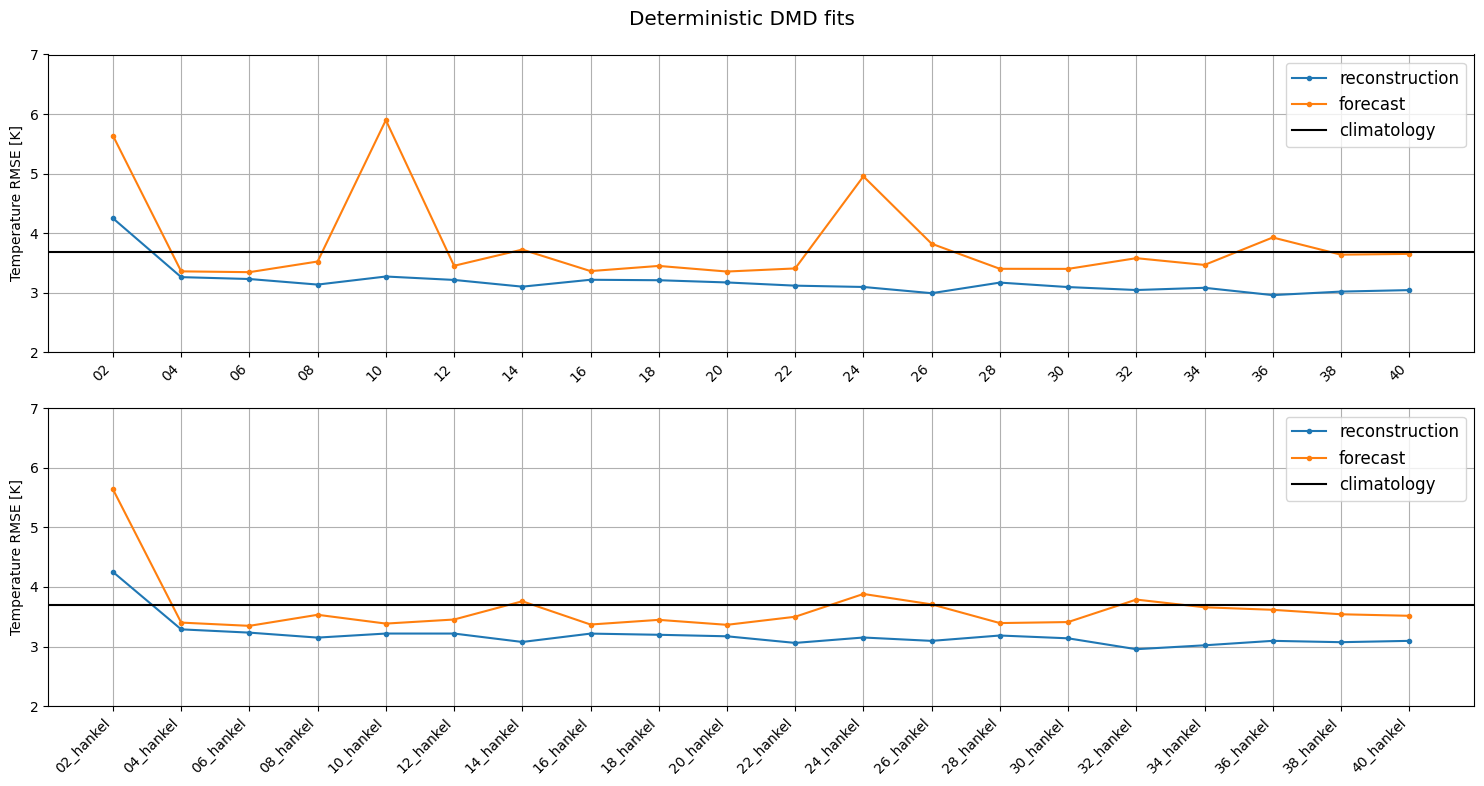

In [7]:
fig, axs = plt.subplots(2, 1, figsize=(15, 8))
axs = axs.flatten()
plt.rcParams.update({'font.size': 12})

def plot_results(axs, keys, reconstruction_vals, forecast_vals):
    axs.plot(reconstruction_vals, ".-", label="reconstruction")
    axs.plot(forecast_vals, ".-", label="forecast")
    axs.set_xticks(range(len(reconstruction_vals)))
    axs.set_xticklabels(list(keys), rotation=45, ha="right")
    axs.set_ylim((2.0, 7.0))
    axs.axhline(
        y=rmse_climatology.mean().values, color='k', linestyle='-', label="climatology"
    )
    axs.set_ylabel("Temperature RMSE [K]")
    axs.grid()
    axs.legend()

keys = [key for key, _ in reconstruction_averages]
reconstruction_vals = [val for _, val in reconstruction_averages]
forecast_vals = [val for _, val in forecast_averages]
plot_results(axs[0], keys, reconstruction_vals, forecast_vals)

keys = [key for key, _ in reconstruction_hankel_averages]
reconstruction_vals = [val for _, val in reconstruction_hankel_averages]
forecast_vals = [val for _, val in forecast_hankel_averages]
plot_results(axs[1], keys, reconstruction_vals, forecast_vals)

fig.suptitle("Deterministic DMD fits")
fig.tight_layout()
plt.show()

## Probabilistic

In [8]:
reconstruction_files = sorted(glob("metrics/probabilistic/reconstruction*"))
forecast_files = sorted(glob("metrics/probabilistic/forecast*"))

In [9]:
reconstructions = {}
reconstructions_hankel = {}
for file in reconstruction_files:
    path = Path(file)
    name = path.name.split(".")[0]
    name = name.split("rmse_")[-1]
    if "hankel" in name:
        reconstructions_hankel[name] = xr.open_dataarray(file)
    else:
        reconstructions[name] = xr.open_dataarray(file)

In [10]:
forecasts = {}
forecasts_hankel = {}
for file in forecast_files:
    path = Path(file)
    name = path.name.split(".")[0]
    name = name.split("rmse_")[-1]
    if "hankel" in name:
        forecasts_hankel[name] = xr.open_dataarray(file)
    else:
        forecasts[name] = xr.open_dataarray(file)

In [11]:
reconstruction_averages = []
reconstruction_hankel_averages = []
forecast_averages = []
forecast_hankel_averages = []

for key in reconstructions.keys():
    reconstruction_averages.append((key, reconstructions[key].mean().values))
    forecast_averages.append((key, forecasts[key].mean().values))

for key in reconstructions_hankel.keys():
    reconstruction_hankel_averages.append(
        (key, reconstructions_hankel[key].mean().values)
    )
    forecast_hankel_averages.append((key, forecasts_hankel[key].mean().values))

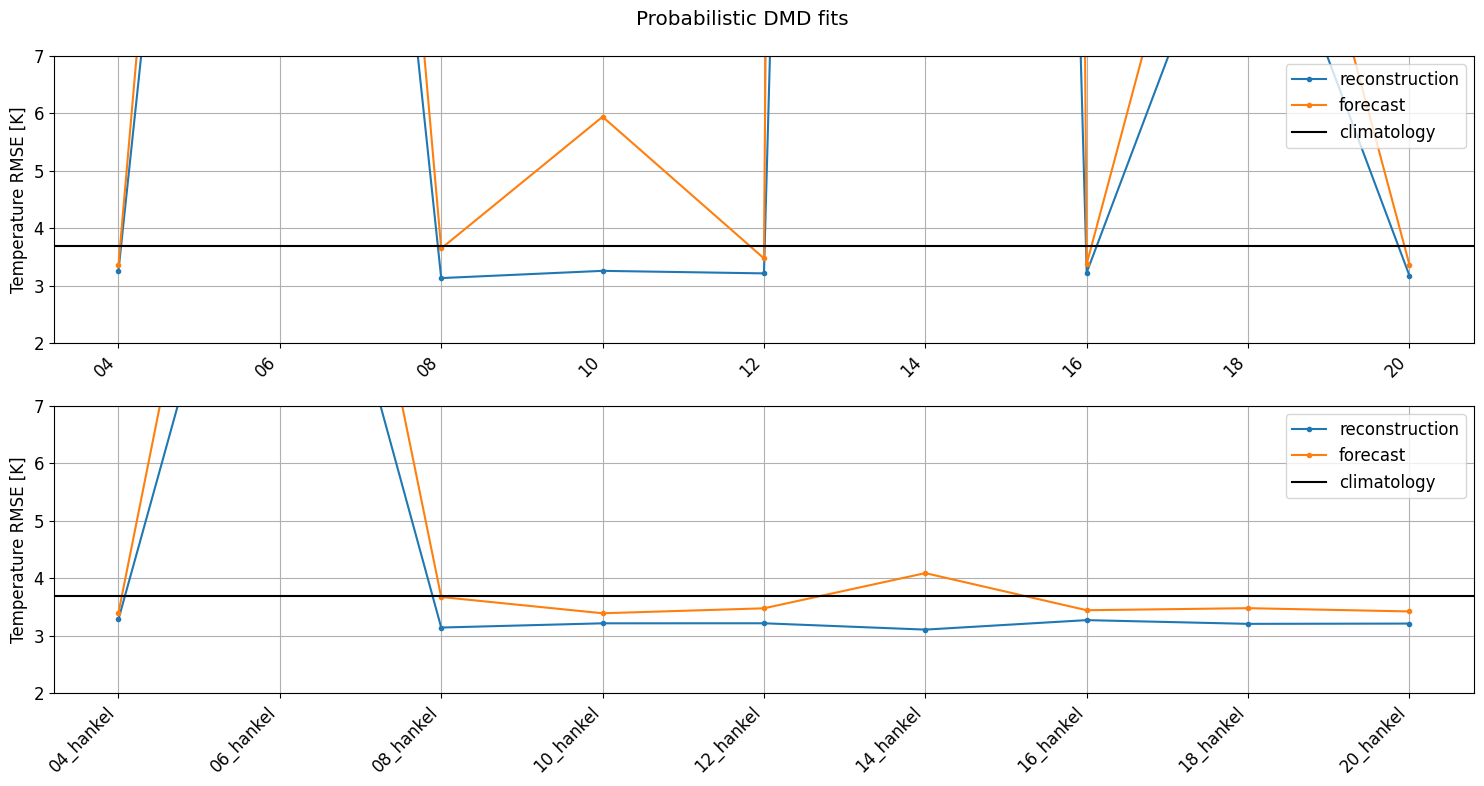

In [12]:
fig, axs = plt.subplots(2, 1, figsize=(15, 8))
axs = axs.flatten()
plt.rcParams.update({'font.size': 12})

def plot_results(axs, keys, reconstruction_vals, forecast_vals):
    axs.plot(reconstruction_vals, ".-", label="reconstruction")
    axs.plot(forecast_vals, ".-", label="forecast")
    axs.set_xticks(range(len(reconstruction_vals)))
    axs.set_xticklabels(list(keys), rotation=45, ha="right")
    axs.set_ylim((2.0, 7.0))
    axs.axhline(
        y=rmse_climatology.mean().values, color='k', linestyle='-', label="climatology"
    )
    axs.set_ylabel("Temperature RMSE [K]")
    axs.grid()
    axs.legend()

keys = [key for key, _ in reconstruction_averages]
reconstruction_vals = [val for _, val in reconstruction_averages]
forecast_vals = [val for _, val in forecast_averages]
plot_results(axs[0], keys, reconstruction_vals, forecast_vals)

keys = [key for key, _ in reconstruction_hankel_averages]
reconstruction_vals = [val for _, val in reconstruction_hankel_averages]
forecast_vals = [val for _, val in forecast_hankel_averages]
plot_results(axs[1], keys, reconstruction_vals, forecast_vals)

fig.suptitle("Probabilistic DMD fits")
fig.tight_layout()
plt.show()